=== Training Detector on FashionMNIST (box around clothing) ===
[Detector] Epoch 1/3, Loss: 0.0988
[Detector] Epoch 2/3, Loss: 0.0927
[Detector] Epoch 3/3, Loss: 0.0927

=== Training Semantic Segmentation (clothing vs background) ===
[SemSeg] Epoch 1/3, Loss: 0.4098
[SemSeg] Epoch 2/3, Loss: 0.1455
[SemSeg] Epoch 3/3, Loss: 0.1177


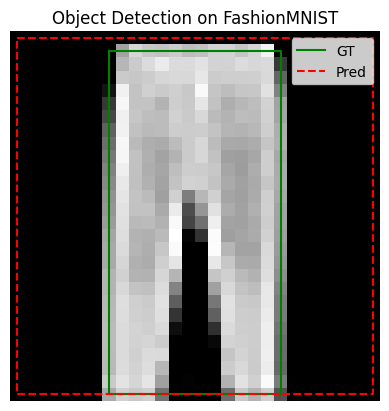

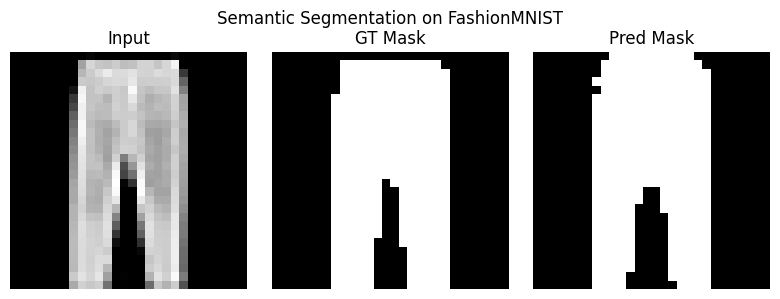

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import random

# ============================================
# 1. Dataset: FashionMNIST + box + mask
# ============================================

class FashionDetSegDataset(Dataset):
    """
    Wraps FashionMNIST:
    - img: 1x28x28 (float in [0,1])
    - label: class id (0..9)
    - mask: 1x28x28, 1 for clothing pixels, 0 for background
    - box: [x1, y1, x2, y2] normalised to [0,1]
    """
    def __init__(self, root="./data", train=True, limit=None, threshold=0.1):
        self.base = datasets.FashionMNIST(
            root=root,
            train=train,
            download=True,
            transform=transforms.ToTensor()
        )
        self.threshold = threshold
        self.indices = list(range(len(self.base))) if limit is None else list(range(limit))

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        base_idx = self.indices[idx]
        img, label = self.base[base_idx]  # img: (1, 28, 28)
        # binary mask: clothing vs background
        # Use first channel (only 1) and threshold
        m = (img[0] > self.threshold).float()  # (28,28)
        # compute bounding box from mask
        coords = m.nonzero(as_tuple=False)  # (N,2) where columns are (y,x)
        if coords.numel() == 0:
            # fallback just in case (shouldn't happen)
            y1, x1, y2, x2 = 0, 0, 27, 27
        else:
            y_min = coords[:, 0].min().item()
            y_max = coords[:, 0].max().item()
            x_min = coords[:, 1].min().item()
            x_max = coords[:, 1].max().item()
            x1, y1, x2, y2 = x_min, y_min, x_max, y_max

        # Normalise coordinates to [0,1]
        H = img.shape[1]  # 28
        W = img.shape[2]  # 28
        box = torch.tensor([x1 / (W - 1),
                            y1 / (H - 1),
                            x2 / (W - 1),
                            y2 / (H - 1)],
                           dtype=torch.float32)

        mask = m.unsqueeze(0)  # (1,28,28)
        target = {
            "label": torch.tensor(label, dtype=torch.long),
            "box": box,
            "mask": mask
        }
        return img, target


# ============================================
# 2. Small CNN backbone
# ============================================

class SmallCNNBackbone(nn.Module):
    """
    Small conv net from 1x28x28 to 64x7x7
    """
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),  # 28x28
            nn.ReLU(),
            nn.MaxPool2d(2),                 # 14x14
            nn.Conv2d(32, 64, 3, padding=1), # 14x14
            nn.ReLU(),
            nn.MaxPool2d(2)                  # 7x7
        )

    def forward(self, x):
        return self.net(x)  # (B,64,7,7)


# ============================================
# 3. Object detection (single box)
# ============================================

class SimpleDetector(nn.Module):
    """
    Predict ONE bounding box [x1,y1,x2,y2] in [0,1].
    """
    def __init__(self):
        super().__init__()
        self.backbone = SmallCNNBackbone()
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 4)  # 4 coords
        )

    def forward(self, x):
        feats = self.backbone(x)
        out = self.head(feats)
        # constrain to [0,1]
        box_pred = torch.sigmoid(out)
        return box_pred  # (B,4)


# ============================================
# 4. Semantic segmentation (binary mask)
# ============================================

class SimpleSegNet(nn.Module):
    """
    Very small encoder-decoder for 1x28x28 -> 1x28x28 (logits).
    """
    def __init__(self):
        super().__init__()
        # Encoder
        self.enc1 = nn.Sequential(nn.Conv2d(1, 16, 3, padding=1), nn.ReLU())
        self.pool1 = nn.MaxPool2d(2)  # 14x14
        self.enc2 = nn.Sequential(nn.Conv2d(16, 32, 3, padding=1), nn.ReLU())
        self.pool2 = nn.MaxPool2d(2)  # 7x7

        # Decoder
        self.up1 = nn.ConvTranspose2d(32, 16, 2, 2)  # 14x14
        self.dec1 = nn.Sequential(nn.Conv2d(16, 16, 3, padding=1), nn.ReLU())
        self.up2 = nn.ConvTranspose2d(16, 16, 2, 2)  # 28x28
        self.dec2 = nn.Sequential(
            nn.Conv2d(16, 16, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 1, 1)  # logits
        )

    def forward(self, x):
        e1 = self.enc1(x)
        p1 = self.pool1(e1)
        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        d1 = self.up1(p2)
        d1 = self.dec1(d1)
        d2 = self.up2(d1)
        out = self.dec2(d2)
        return out  # (B,1,28,28)

# ============================================
# 5. Training loops
# ============================================

def train_detector(model, loader, device, epochs=3, lr=1e-3):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.L1Loss()

    for ep in range(epochs):
        model.train()
        total_loss = 0.0
        for imgs, targets in loader:
            imgs = imgs.to(device)
            boxes_gt = targets["box"].to(device)

            opt.zero_grad()
            boxes_pred = model(imgs)
            loss = criterion(boxes_pred, boxes_gt)
            loss.backward()
            opt.step()

            total_loss += loss.item() * imgs.size(0)
        avg_loss = total_loss / len(loader.dataset)
        print(f"[Detector] Epoch {ep+1}/{epochs}, Loss: {avg_loss:.4f}")


def train_semseg(model, loader, device, epochs=3, lr=1e-3):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    for ep in range(epochs):
        model.train()
        total_loss = 0.0
        for imgs, targets in loader:
            imgs = imgs.to(device)
            masks_gt = targets["mask"].to(device)

            opt.zero_grad()
            logits = model(imgs)
            loss = criterion(logits, masks_gt)
            loss.backward()
            opt.step()

            total_loss += loss.item() * imgs.size(0)
        avg_loss = total_loss / len(loader.dataset)
        print(f"[SemSeg] Epoch {ep+1}/{epochs}, Loss: {avg_loss:.4f}")

# ============================================
# 6. Visualisation helpers
# ============================================

def denorm_box(box, H=28, W=28):
    """
    box in [0,1], return pixel coords (x1,y1,x2,y2).
    """
    x1 = box[0].item() * (W - 1)
    y1 = box[1].item() * (H - 1)
    x2 = box[2].item() * (W - 1)
    y2 = box[3].item() * (H - 1)
    return x1, y1, x2, y2


def show_detection(img, gt_box, pred_box, title="Detection"):
    """
    img: (1,28,28), gt_box & pred_box in [0,1]
    """
    H, W = img.shape[1], img.shape[2]
    img_np = img.squeeze().cpu().numpy()

    x1g, y1g, x2g, y2g = denorm_box(gt_box, H, W)
    x1p, y1p, x2p, y2p = denorm_box(pred_box, H, W)

    plt.imshow(img_np, cmap="gray")
    # GT: green
    plt.plot(
        [x1g, x2g, x2g, x1g, x1g],
        [y1g, y1g, y2g, y2g, y1g],
        "g-",
        label="GT"
    )
    # Pred: red dashed
    plt.plot(
        [x1p, x2p, x2p, x1p, x1p],
        [y1p, y1p, y2p, y2p, y1p],
        "r--",
        label="Pred"
    )
    plt.legend()
    plt.title(title)
    plt.axis("off")
    plt.show()


def show_masks(img, gt_mask, pred_mask_logits, title="Segmentation"):
    """
    img: (1,28,28), gt_mask: (1,28,28), pred_mask_logits: (1,28,28)
    """
    img_np = img.squeeze().cpu().numpy()
    gt_np = gt_mask.squeeze().cpu().numpy()
    pred_prob = torch.sigmoid(pred_mask_logits).squeeze().detach().cpu().numpy()
    pred_bin = (pred_prob > 0.5).astype(float)

    fig, axs = plt.subplots(1, 3, figsize=(8, 3))
    axs[0].imshow(img_np, cmap="gray")
    axs[0].set_title("Input")
    axs[1].imshow(gt_np, cmap="gray")
    axs[1].set_title("GT Mask")
    axs[2].imshow(pred_bin, cmap="gray")
    axs[2].set_title("Pred Mask")
    for a in axs:
        a.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


# ============================================
# 7. All together
# ============================================

if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Use subsets to keep training quick in class
    train_dataset = FashionDetSegDataset(train=True, limit=8000)
    test_dataset = FashionDetSegDataset(train=False, limit=1000)

    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

    # 1) Object Detection
    print("=== Training Detector on FashionMNIST (box around clothing) ===")
    det_model = SimpleDetector()
    train_detector(det_model, train_loader, device, epochs=3, lr=1e-3)

    # 2) Semantic Segmentation
    print("\n=== Training Semantic Segmentation (clothing vs background) ===")
    semseg_model = SimpleSegNet()
    train_semseg(semseg_model, train_loader, device, epochs=3, lr=1e-3)

    # ---------------------------------------
    # Visualise on a few test examples
    # ---------------------------------------
    det_model.eval()
    semseg_model.eval()

    # pick a random test sample
    idx = random.randint(0, len(test_dataset) - 1)
    img, target = test_dataset[idx]  # img: (1,28,28)

    img_batch = img.unsqueeze(0).to(device)

    with torch.no_grad():
        # Detection
        box_pred = det_model(img_batch)[0].cpu()
        # Semantic segmentation
        mask_logits_sem = semseg_model(img_batch)[0].cpu()

    # Visualise detection
    show_detection(img, target["box"], box_pred, title="Object Detection on FashionMNIST")

    # Visualise semantic segmentation
    show_masks(img, target["mask"], mask_logits_sem, title="Semantic Segmentation on FashionMNIST")
